# Assignment 4 - LoRA

Adapted from https://colab.research.google.com/github/huggingface/trl/blob/main/examples/notebooks/sft_trl_lora_qlora.ipynb?authuser=2

## Key concepts

- **SFT**: Trains models from example input-output pairs to align behavior with human preferences.
- **LoRA**: Updates only a few low-rank parameters, reducing training cost and memory.
- **QLoRA**: A quantized version of LoRA that enables even larger models to fit on small GPUs.
- **TRL**: The Hugging Face library that makes fine-tuning and reinforcement learning simple and efficient.

Learn how to perform **Supervised Fine-Tuning (SFT)** with **LoRA/QLoRA** using **TRL**.

## Install dependencies

We'll install **TRL** with the **PEFT** extra, which ensures all main dependencies such as **Transformers** and **PEFT** (a package for parameter-efficient fine-tuning, e.g., LoRA/QLoRA) are included. Additionally, we'll install **trackio** to log and monitor our experiments, and **bitsandbytes** to enable quantization of LLMs, reducing memory consumption for both inference and training.

In [ ]:
# Install all dependencies first — do NOT run pip installs later in the notebook
!pip install -Uq "trl[peft]" trackio bitsandbytes "liger-kernel>=0.3.0"
!pip install --no-cache-dir protobuf==6.33.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.5/276.5 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 18.3 MB/s eta 0:00:00


### Log in to Hugging Face

Log in to your **Hugging Face** account to save your fine-tuned model, track your experiment results directly on the Hub or access gated models. You can find your **access token** on your [account settings page](https://huggingface.co/settings/tokens).

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

## Configuration

Set your HuggingFace username and choose which dataset to run.

**Dataset 1:** `TeichAI/claude-4.5-opus-high-reasoning-250x` — 250 examples of Claude reasoning with `<think>` chain-of-thought blocks

**Dataset 2:** `HuggingFaceH4/self_instruct` — general instruction-following examples

To run for Dataset 2, change `DATASET_NUMBER = 1` to `DATASET_NUMBER = 2` and re-run from this cell onward.

In [ ]:

HF_USERNAME   = "xillfe"
DATASET_NUMBER = 1


DATASETS = {
    1: "TeichAI/claude-4.5-opus-high-reasoning-250x",
    2: "HuggingFaceH4/self_instruct",
}

dataset_name = DATASETS[DATASET_NUMBER]
output_dir   = f"LFM2-2.6B-SFT-dataset{DATASET_NUMBER}"
model_id     = "LiquidAI/LFM2-2.6B"

print(f"Dataset : {dataset_name}")
print(f"Model   : {model_id}")
print(f"Output  : {output_dir}")


Dataset : TeichAI/claude-4.5-opus-high-reasoning-250x
Model   : LiquidAI/LFM2-2.6B
Output  : LFM2-2.6B-SFT-dataset1


## Load Dataset

In this step, we load the [**dataset of your choice**](https://huggingface.co/datasets/) from the Hugging Face Hub using the `datasets` library.  

For efficiency, we'll load only the **training split**:

In [ ]:
from datasets import load_dataset

train_dataset = load_dataset(dataset_name, split="train")
print(train_dataset)


Repo card metadata block was not found. Setting CardData to empty.


Dataset({
    features: ['messages'],
    num_rows: 250
})


Let's explore the training dataset.

In [ ]:
train_dataset

Dataset({
    features: ['messages'],
    num_rows: 250
})

Let's see a full example to understand the internal structure:

In [ ]:
train_dataset[0]

{'messages': [{'role': 'system', 'content': ''},
  {'role': 'user',
   'content': 'Develop Python code to implement a recommendation system using collaborative filtering.'},
  {'role': 'assistant',
   'content': '<think>The user wants me to implement a recommendation system using collaborative filtering in Python. I\'ll create a comprehensive implementation that covers:\n\n1. **User-Based Collaborative Filtering** - Find similar users and recommend items they liked\n2. **Item-Based Collaborative Filtering** - Find similar items and recommend based on user\'s past preferences\n3. **Matrix Factorization (SVD)** - Latent factor model\n\nI\'ll include:\n- Data preprocessing\n- Similarity calculations (cosine, Pearson correlation)\n- Neighborhood-based methods\n- Matrix factorization using SVD\n- Evaluation metrics (RMSE, MAE, Precision, Recall)\n- A practical example with movie ratings\n\nLet me create a well-structured, comprehensive implementation.</think> # Collaborative Filtering Recom

Now, let's remove any not required columns. Careful not to remove everything!

In [ ]:
if DATASET_NUMBER == 1:
    train_dataset = load_dataset(dataset_name_1, split="train")


    cols_to_remove = [col for col in train_dataset.column_names if col != "messages"]
    if cols_to_remove:
        print(f"Removing columns: {cols_to_remove}")
        train_dataset = train_dataset.remove_columns(cols_to_remove)
    else:
        print("No extra columns to remove — dataset already clean.")

elif DATASET_NUMBER == 2:
    train_dataset = load_dataset(dataset_name_2, split="train")


    def convert_to_messages(example):
        return {
            "messages": [
                {"role": "user",    "content": example["prompt"]},
                {"role": "assistant", "content": example["completion"]}
            ]
        }

    train_dataset = train_dataset.map(convert_to_messages)
    cols_to_remove = [col for col in train_dataset.column_names if col != "messages"]
    if cols_to_remove:
        print(f"Removing columns: {cols_to_remove}")
        train_dataset = train_dataset.remove_columns(cols_to_remove)

print(train_dataset)
print(train_dataset[0])

Repo card metadata block was not found. Setting CardData to empty.


No extra columns to remove — dataset already clean.
Dataset({
    features: ['messages'],
    num_rows: 250
})
{'messages': [{'role': 'system', 'content': ''}, {'role': 'user', 'content': 'Develop Python code to implement a recommendation system using collaborative filtering.'}, {'role': 'assistant', 'content': '<think>The user wants me to implement a recommendation system using collaborative filtering in Python. I\'ll create a comprehensive implementation that covers:\n\n1. **User-Based Collaborative Filtering** - Find similar users and recommend items they liked\n2. **Item-Based Collaborative Filtering** - Find similar items and recommend based on user\'s past preferences\n3. **Matrix Factorization (SVD)** - Latent factor model\n\nI\'ll include:\n- Data preprocessing\n- Similarity calculations (cosine, Pearson correlation)\n- Neighborhood-based methods\n- Matrix factorization using SVD\n- Evaluation metrics (RMSE, MAE, Precision, Recall)\n- A practical example with movie ratings\n\nL

In [ ]:
train_dataset[0]

{'messages': [{'role': 'system', 'content': ''},
  {'role': 'user',
   'content': 'Develop Python code to implement a recommendation system using collaborative filtering.'},
  {'role': 'assistant',
   'content': '<think>The user wants me to implement a recommendation system using collaborative filtering in Python. I\'ll create a comprehensive implementation that covers:\n\n1. **User-Based Collaborative Filtering** - Find similar users and recommend items they liked\n2. **Item-Based Collaborative Filtering** - Find similar items and recommend based on user\'s past preferences\n3. **Matrix Factorization (SVD)** - Latent factor model\n\nI\'ll include:\n- Data preprocessing\n- Similarity calculations (cosine, Pearson correlation)\n- Neighborhood-based methods\n- Matrix factorization using SVD\n- Evaluation metrics (RMSE, MAE, Precision, Recall)\n- A practical example with movie ratings\n\nLet me create a well-structured, comprehensive implementation.</think> # Collaborative Filtering Recom

You will have to remove the below or rework it for your dataset!

In [ ]:
train_dataset[0]

{'messages': [{'role': 'system', 'content': ''},
  {'role': 'user',
   'content': 'Develop Python code to implement a recommendation system using collaborative filtering.'},
  {'role': 'assistant',
   'content': '<think>The user wants me to implement a recommendation system using collaborative filtering in Python. I\'ll create a comprehensive implementation that covers:\n\n1. **User-Based Collaborative Filtering** - Find similar users and recommend items they liked\n2. **Item-Based Collaborative Filtering** - Find similar items and recommend based on user\'s past preferences\n3. **Matrix Factorization (SVD)** - Latent factor model\n\nI\'ll include:\n- Data preprocessing\n- Similarity calculations (cosine, Pearson correlation)\n- Neighborhood-based methods\n- Matrix factorization using SVD\n- Evaluation metrics (RMSE, MAE, Precision, Recall)\n- A practical example with movie ratings\n\nLet me create a well-structured, comprehensive implementation.</think> # Collaborative Filtering Recom

## Load model and configure LoRA/QLoRA

This notebook can be used with two fine-tuning methods. By default, it is set up for **QLoRA**, which includes quantization using `BitsAndBytesConfig`. If you prefer to use standard **LoRA** without quantization, simply comment out the `BitsAndBytesConfig` configuration.

Below, choose your **preferred model**. All of the options have been tested on **free Colab instances**.

**Note** that the larger models *may* cause problems in terms of running via a free Colab instance on the later steps. You may want to pick a smaller model if you're finding you're getting out of memory errors.

In [ ]:

print(f"Using model : {model_id}")
print(f"Output dir  : {output_dir}")


Using model : LiquidAI/LFM2-2.6B
Output dir  : LFM2-2.6B-SFT-dataset1


Let's load the selected model using `transformers`, configuring QLoRA via `bitsandbytes` (you can remove it if doing LoRA). We don't need to configure the tokenizer since the trainer takes care of that automatically.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    attn_implementation="sdpa",
    torch_dtype=torch.float16,
    use_cache=True,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )
)
print("Model loaded.")


Model loaded.


The following cell defines LoRA (or QLoRA if needed). When training with LoRA/QLoRA, we use a **base model** (the one selected above) and, instead of modifying its original weights, we fine-tune a **LoRA adapter** — a lightweight layer that enables efficient and memory-friendly training. The **`target_modules`** specify which parts of the model (e.g., attention or projection layers) will be adapted by LoRA during fine-tuning.

In [ ]:
from peft import LoraConfig

peft_config = LoraConfig(
    r=32,
    lora_alpha=32,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj",],
)

## Train model

We'll configure **SFT** using `SFTConfig`, keeping the parameters minimal so the training fits on a free Colab instance. You can adjust these settings if more resources are available. For full details on all available parameters, check the [TRL SFTConfig documentation](https://huggingface.co/docs/trl/sft_trainer#trl.SFTConfig).

In [ ]:
from trl import SFTConfig

training_args = SFTConfig(
    # Training schedule / optimization
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 4,
    warmup_steps = 5,
    num_train_epochs = 1,
    max_steps = 50,
    learning_rate = 2e-4,
    optim = "paged_adamw_8bit",

    # Logging / reporting
    logging_steps = 1,
    report_to = "trackio",
    trackio_space_id = output_dir,
    output_dir = output_dir,

    max_length = 1024,
    use_liger_kernel = True,
    activation_offloading = True,

    # Hub integration
    push_to_hub = True,
)


Configure the [SFT Trainer](https://huggingface.co/docs/trl/en/sft_trainer). We pass the previously configured `training_args`. We don't use eval dataset to maintain memory usage low but you can configure it.

In [ ]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    peft_config=peft_config
)

Tokenizing train dataset:   0%|          | 0/250 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/250 [00:00<?, ? examples/s]

Show memory stats before training

In [ ]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
6.105 GB of memory reserved.


And train! Note this may take up to 90 minutes depending on your settings. DON'T RUN THIS AGAIN IF IT SAVED OKAY

In [ ]:
trainer_stats = trainer.train()

* Trackio project initialized: huggingface
* Trackio metrics will be synced to Hugging Face Dataset: xillfe/LFM2-2.6B-SFT-dataset2-dataset
* Creating new space: https://huggingface.co/spaces/xillfe/LFM2-2.6B-SFT-dataset2
* View dashboard by going to: https://xillfe-LFM2-2.6B-SFT-dataset2.hf.space/


* NVIDIA GPU detected, enabling automatic GPU metrics logging
* Created new run: xillfe-1773547693


/usr/local/lib/python3.12/dist-packages/transformers/trainer.py:4020: UserWarning: liger-kernel did not return token_accuracy when requested. The mean_token_accuracy metric will not be logged. This is unexpected; please report it to the liger-kernel repository.
  loss = self.compute_loss(model, inputs, num_items_in_batch=num_items_in_batch)


Step,Training Loss
1,3.604000
2,4.930200
3,5.662400
4,4.139200
5,3.533900
6,4.017200
7,4.165200
8,3.949300
9,5.009800
10,3.116700


* Run finished. Uploading logs to Trackio Space (please wait...)


Show memory stats after training

In [ ]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)

print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

211.0175 seconds used for training.
3.52 minutes used for training.
Peak reserved memory = 6.105 GB.
Peak reserved memory for training = 0.0 GB.
Peak reserved memory % of max memory = 41.921 %.
Peak reserved memory for training % of max memory = 0.0 %.


## Saving fine tuned model

In this step, we save the fine-tuned model both **locally** and to the **Hugging Face Hub** using the credentials from your account. DON'T RUN THIS AGAIN IF IT SAVED OKAY

In [ ]:
trainer.save_model(output_dir)
trainer.push_to_hub(dataset_name=dataset_name)
print(f"Model saved to HuggingFace: {HF_USERNAME}/{output_dir}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ataset2/training_args.bin: 100%|##########| 6.22kB / 6.22kB            

  ...adapter_model.safetensors: 100%|##########| 4.73MB / 4.73MB            

  ...adapter_model.safetensors: 100%|##########| 4.73MB / 4.73MB            

...

New Data Upload               : |          |  0.00B /  0.00B            

  ...ataset2/training_args.bin: 100%|##########| 6.22kB / 6.22kB            

  ...adapter_model.safetensors: 100%|##########| 4.73MB / 4.73MB            

  ...adapter_model.safetensors: 100%|##########| 4.73MB / 4.73MB            

Model saved to HuggingFace: xillfe/LFM2-2.6B-SFT-dataset2


## Load the fine-tuned model and run inference

Now, let's test our fine-tuned model by loading the **LoRA/QLoRA adapter** and performing **inference**. We'll start by loading the **base model**, then attach the adapter to it, creating the final fine-tuned model ready for evaluation.

**NOTE**: You must replace 'guzdial' below with your own huggingface account name.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

adapter_model = f"{HF_USERNAME}/{output_dir}"

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    attn_implementation="sdpa",
    torch_dtype=torch.float16,
    use_cache=True,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
print(f"Base model loaded. Adapter will load from: {adapter_model}")


Base model loaded. Adapter will load from: xillfe/LFM2-2.6B-SFT-dataset1


Here create a sample message using your dataset's structure. NOTE: You will need to do this multiple times.

In [ ]:
messages = [
    {
        'role': 'user',
        'content': 'Develop Python code to implement a recommendation system using collaborative filtering.'
    }
]

Let's first check what's the output for the base model, without the adapter.

In [ ]:
text = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=False
)
model_inputs = tokenizer([text], return_tensors="pt").to(base_model.device)

generated_ids = base_model.generate(
    **model_inputs,
    max_new_tokens=512
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):]

# Decode and extract model response
generated_text = tokenizer.decode(output_ids, skip_special_tokens=True)
print(generated_text)

Here's a basic implementation of a collaborative filtering recommendation system using Python and the `scikit-learn` library. This example uses user-item interaction data and implements a simple user-based collaborative filtering approach.

```python
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Sample user-item interaction data
data = {
    'user_id': [1, 1, 1, 2, 2, 3, 3, 4, 4, 4],
    'item_id': [101, 102, 103, 101, 102, 104, 105, 101, 102, 103],
    'rating': [5, 4, 3, 5, 4, 1, 2, 5, 4, 3]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Standardize ratings
scaler = StandardScaler()
df['rating_scaled'] = scaler.fit_transform(df['rating'].values.reshape(-1, 1))

# Compute user similarity matrix
user_similarity = cosine_similarity(df['user_id'].values.reshape(-1, 1), df['user_id'].values.reshape(-1, 1))

# Function to get top-N recommendations for a user
def get_recommendations(user_id, top_n=3):
    #

Did the base model meet your expectations? Let's now load the fine-tuned model and check its answer.

In [ ]:
fine_tuned_model = PeftModel.from_pretrained(base_model, adapter_model)
print(f"Fine-tuned adapter loaded from {adapter_model}")


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Fine-tuned adapter loaded from xillfe/LFM2-2.6B-SFT-dataset1


In [ ]:
text = tokenizer.apply_chat_template(
    messages, add_generation_prompt=True, tokenize=False
)
model_inputs = tokenizer([text], return_tensors="pt").to(fine_tuned_model.device)

generated_ids = fine_tuned_model.generate(
    **model_inputs,
    max_new_tokens=512
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):]

# Decode and extract model response
generated_text = tokenizer.decode(output_ids, skip_special_tokens=True)
print(generated_text)

Here's a basic implementation of a collaborative filtering recommendation system using Python and the `scikit-learn` library. This example uses user-item interaction data and implements a simple user-based collaborative filtering approach.

```python
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Sample user-item interaction data
data = {
    'user_id': [1, 1, 1, 2, 2, 3, 3, 4, 4, 4],
    'item_id': [101, 102, 103, 101, 102, 104, 105, 101, 102, 103],
    'rating': [5, 4, 3, 5, 4, 1, 2, 5, 4, 3]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Standardize ratings
scaler = StandardScaler()
df['rating_scaled'] = scaler.fit_transform(df['rating'].values.reshape(-1, 1))

# Compute user similarity matrix
user_similarity = cosine_similarity(df['user_id'].values.reshape(-1, 1), df['user_id'].values.reshape(-1, 1))

# Function to get top-N recommendations for a user
def get_recommendations(user_id, top_n=3):
    #

In [ ]:
def run_inference(model, tokenizer, messages, max_new_tokens=512, temperature=0.7):
    """Run inference and return the generated text."""
    text = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    inputs = tokenizer([text], return_tensors="pt").to(model.device)
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=True,
        )
    output_ids = generated_ids[0][len(inputs.input_ids[0]):]
    return tokenizer.decode(output_ids, skip_special_tokens=True)


def compare(messages, max_new_tokens=512):
    """Print base and fine-tuned responses side by side."""
    prompt_text = messages[0]['content']
    print(f"{'='*70}")
    print(f"PROMPT: {prompt_text[:200]}")
    print(f"{'-'*70}")
    print("BASE MODEL:")
    base_out = run_inference(base_model, tokenizer, messages, max_new_tokens)
    print(base_out)
    print(f"{'-'*70}")
    print("FINE-TUNED MODEL:")
    ft_out = run_inference(fine_tuned_model, tokenizer, messages, max_new_tokens)
    print(ft_out)
    print(f"{'='*70}\n")
    return base_out, ft_out

print("Helper functions defined.")


Helper functions defined.


If everything went well it should be different! If not, things may have gone wrong.

## Test Prompts — 10 Inputs

Run each prompt through both the base and fine-tuned model.

**For Dataset 1** (TeichAI reasoning dataset): prompts are coding/technical to elicit `<think>` reasoning blocks.

**For Dataset 2** (self_instruct): prompts are general instruction-following tasks.

The `compare()` function automatically runs both models and prints both outputs.

### Prompt 1

In [ ]:
# Prompt 1
# Dataset 1 prompt: Write a Python function that finds the longest palindromic substring in a string.
# Dataset 2 prompt: Write a professional email declining a job offer politely.

prompt_ds1 = "Write a Python function that finds the longest palindromic substring in a string."
prompt_ds2 = "Write a professional email declining a job offer politely."

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_1, ft_out_1 = compare(messages)


PROMPT: Write a Python function that finds the longest palindromic substring in a string.
----------------------------------------------------------------------
BASE MODEL:
```python
def longest_palindromic_substring(s: str) -> str:
    """
    Returns the longest palindromic substring in a given string.

    Args:
        s (str): The input string.

    Returns:
        str: The longest palindromic substring. If there are multiple, returns the first one found.
    """
    def expand_around_center(s, left: int, right: int) -> str:
        while left >= 0 and right < len(s) and s[left] == s[right]:
            left -= 1
            right += 1
        return s[left + 1:right]

    longest = ""
    for i in range(len(s)):
        # Odd-length palindromes
        odd_palindrome = expand_around_center(s, i, i)
        # Even-length palindromes
        even_palindrome = expand_around_center(s, i, i + 1)

        # Update longest palindrome
        longest = max([longest, odd_palindrome, even

### Prompt 2

In [ ]:
# Prompt 2
# Dataset 1 prompt: Explain the difference between a stack and a queue, and give a use case for each.
# Dataset 2 prompt: Summarise the main causes of World War I in three bullet points.

prompt_ds1 = "Explain the difference between a stack and a queue, and give a use case for each."
prompt_ds2 = "Summarise the main causes of World War I in three bullet points."

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_2, ft_out_2 = compare(messages)


PROMPT: Explain the difference between a stack and a queue, and give a use case for each.
----------------------------------------------------------------------
BASE MODEL:
A stack and a queue are both linear data structures that store elements in a specific order, but they differ in how elements are added and removed.

**Stack:**

A stack follows the Last-In-First-Out (LIFO) principle, meaning the last element added is the first one removed. Think of a physical stack of plates: you add plates on top and remove plates from the top.

Example use case:

* Evaluating postfix expressions (also known as Reverse Polish Notation)
* Implementing recursive algorithms iteratively
* Managing function calls and returns in programming languages

Here's a simple example in Python:

```python
stack = []
stack.append(1)  # push 1 onto the stack
stack.append(2)  # push 2 onto the stack
print(stack.pop())  # remove and return 2
print(stack.pop())  # remove and return 1
```

**Queue:**

A queue follows t

### Prompt 3

In [ ]:
# Prompt 3
# Dataset 1 prompt: Implement a binary search tree with insert, search, and delete methods in Python.
# Dataset 2 prompt: Give me a 7-day meal plan for someone who is lactose intolerant.

prompt_ds1 = "Implement a binary search tree with insert, search, and delete methods in Python."
prompt_ds2 = "Give me a 7-day meal plan for someone who is lactose intolerant."

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_3, ft_out_3 = compare(messages)


PROMPT: Implement a binary search tree with insert, search, and delete methods in Python.
----------------------------------------------------------------------
BASE MODEL:
```python
class Node:
    def __init__(self, key):
        self.key = key
        self.left = None
        self.right = None

class BinarySearchTree:
    def __init__(self):
        self.root = None

    def insert(self, key):
        if not self.root:
            self.root = Node(key)
        else:
            self._insert(self.root, key)

    def _insert(self, node, key):
        if key < node.key:
            if node.left:
                self._insert(node.left, key)
            else:
                node.left = Node(key)
        elif key > node.key:
            if node.right:
                self._insert(node.right, key)
            else:
                node.right = Node(key)
        # Duplicate keys are not allowed

    def search(self, key):
        return self._search(self.root, key)

    def _search(self, n

### Prompt 4

In [ ]:
# Prompt 4
# Dataset 1 prompt: What is the time complexity of quicksort in the best, average, and worst cases? Explain why.
# Dataset 2 prompt: What are three strategies for improving time management at work?

prompt_ds1 = "What is the time complexity of quicksort in the best, average, and worst cases? Explain why."
prompt_ds2 = "What are three strategies for improving time management at work?"

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_4, ft_out_4 = compare(messages)


PROMPT: What is the time complexity of quicksort in the best, average, and worst cases? Explain why.
----------------------------------------------------------------------
BASE MODEL:
The time complexity of quicksort varies depending on the partitioning strategy and the distribution of input data. Here's a breakdown of its performance:

### **Best Case**:  
- **Time Complexity**: \(O(n \log n)\)  
- **Explanation**: Occurs when the pivot selection consistently divides the array into two nearly equal halves (e.g., using median-of-three or randomized pivot selection). This leads to balanced recursion and optimal divide-and-conquer efficiency.  
- **Why**: Each partitioning step splits the array into two subarrays of sizes \( \lfloor n/2 \rfloor \) and \( \lceil n/2 \rceil \), reducing the problem size by half logarithmically.  

### **Average Case**:  
- **Time Complexity**: \(O(n \log n)\)  
- **Explanation**: Even without optimal pivot selection, quicksort typically achieves \(O(n \log

### Prompt 5

In [ ]:
# Prompt 5
# Dataset 1 prompt: Write a Python decorator that caches function results (memoization).
# Dataset 2 prompt: Write a short persuasive paragraph arguing that remote work increases productivity.

prompt_ds1 = "Write a Python decorator that caches function results (memoization)."
prompt_ds2 = "Write a short persuasive paragraph arguing that remote work increases productivity."

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_5, ft_out_5 = compare(messages)


PROMPT: Write a Python decorator that caches function results (memoization).
----------------------------------------------------------------------
BASE MODEL:
Certainly! Below is a Python implementation of a memoization decorator using a dictionary to store cached results. This decorator will cache the results of function calls based on their arguments, so that subsequent calls with the same arguments return the cached result instead of recomputing it.

```python
def memoize(func):
    cache = {}

    def wrapper(*args):
        if args in cache:
            print(f"Returning cached result for {args}")
            return cache[args]
        
        # Compute the result and cache it
        result = func(*args)
        cache[args] = result
        return result

    return wrapper

# Example usage:
@memoize
def fibonacci(n):
    if n < 2:
        return n
    return fibonacci(n - 1) + fibonacci(n - 2)

# Testing the memoized fibonacci function
print(fibonacci(10))  # This will compute

### Prompt 6

In [ ]:
# Prompt 6
# Dataset 1 prompt: Explain how gradient descent works and why learning rate matters.
# Dataset 2 prompt: Explain photosynthesis in simple terms for a 10-year-old.

prompt_ds1 = "Explain how gradient descent works and why learning rate matters."
prompt_ds2 = "Explain photosynthesis in simple terms for a 10-year-old."

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_6, ft_out_6 = compare(messages)


PROMPT: Explain how gradient descent works and why learning rate matters.
----------------------------------------------------------------------
BASE MODEL:
<think>
Okay, so I need to explain how gradient descent works and why the learning rate is important. Let me start by recalling what I know about gradient descent. From what I remember, gradient descent is an optimization algorithm used in machine learning to minimize a loss function. It's like finding the lowest point in a landscape by taking steps in the direction of the steepest descent. But I should get more precise here.

First, the basic idea: you start with some initial parameters (like weights in a neural network) and then iteratively update them to reduce the loss. The loss function measures how well the model is performing. So, gradient descent works by calculating the gradient of the loss function with respect to the parameters. The gradient points in the direction of the most rapid increase, so moving in the opposite di

### Prompt 7

In [ ]:
# Prompt 7
# Dataset 1 prompt: Implement a simple neural network layer (linear + ReLU) from scratch using NumPy.
# Dataset 2 prompt: List five ways a small business can reduce operating costs.

prompt_ds1 = "Implement a simple neural network layer (linear + ReLU) from scratch using NumPy."
prompt_ds2 = "List five ways a small business can reduce operating costs."

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_7, ft_out_7 = compare(messages)


PROMPT: Implement a simple neural network layer (linear + ReLU) from scratch using NumPy.
----------------------------------------------------------------------
BASE MODEL:
Here's a simple implementation of a linear + ReLU neural network layer using NumPy:

```python
import numpy as np

def relu(x):
    """Rectified Linear Unit activation function"""
    return np.maximum(0, x)

def linear_layer(input_data, weights, bias, activation=None):
    """
    Linear layer with optional activation function.

    Args:
        input_data (np.ndarray): Input data
        weights (np.ndarray): Weight matrix
        bias (np.ndarray): Bias vector
        activation (callable): Optional activation function

    Returns:
        np.ndarray: Output after linear transformation and activation
    """
    # Linear transformation
    linear_output = np.dot(input_data, weights) + bias

    # Apply ReLU activation if provided
    if activation is not None:
        linear_output = activation(linear_output)



### Prompt 8

In [ ]:
# Prompt 8
# Dataset 1 prompt: What is the difference between SQL INNER JOIN, LEFT JOIN, and FULL OUTER JOIN?
# Dataset 2 prompt: Write a haiku about autumn leaves.

prompt_ds1 = "What is the difference between SQL INNER JOIN, LEFT JOIN, and FULL OUTER JOIN?"
prompt_ds2 = "Write a haiku about autumn leaves."

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_8, ft_out_8 = compare(messages)


PROMPT: What is the difference between SQL INNER JOIN, LEFT JOIN, and FULL OUTER JOIN?
----------------------------------------------------------------------
BASE MODEL:
In SQL, `INNER JOIN`, `LEFT JOIN`, and `FULL OUTER JOIN` are used to combine rows from two or more tables based on a related column. Here's a brief overview of each:

1. **INNER JOIN**: Returns only the rows that have a match in both tables. It's the most common type of join, and it excludes any rows without a match in either table.

   Example: If you have two tables, `Customers` and `Orders`, an `INNER JOIN` would only return customers who have placed orders.

   ```sql
SELECT *
FROM Customers
INNER JOIN Orders ON Customers.CustomerID = Orders.CustomerID;
```

2. **LEFT JOIN** (also known as `LEFT OUTER JOIN`): Returns all rows from the left table (`LeftTable`) and the matching rows from the right table (`RightTable`). If there's no match, the result is `NULL` on the right side.

   Example: A `LEFT JOIN` would retur

### Prompt 9

In [ ]:
# Prompt 9
# Dataset 1 prompt: Write a Python class implementing a min-heap data structure.
# Dataset 2 prompt: What are the pros and cons of electric vehicles compared to petrol cars?

prompt_ds1 = "Write a Python class implementing a min-heap data structure."
prompt_ds2 = "What are the pros and cons of electric vehicles compared to petrol cars?"

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_9, ft_out_9 = compare(messages)


PROMPT: Write a Python class implementing a min-heap data structure.
----------------------------------------------------------------------
BASE MODEL:
```python
class MinHeap:
    def __init__(self):
        self.heap = []

    def insert(self, value):
        self.heap.append(value)
        self._heapify_up(len(self.heap) - 1)

    def extract_min(self):
        if len(self.heap) == 0:
            raise IndexError("Heap is empty")
        if len(self.heap) == 1:
            return self.heap.pop()
        min_value = self.heap[0]
        self.heap[0] = self.heap.pop()
        self._heapify_down(0)
        return min_value

    def _heapify_up(self, index):
        parent_index = (index - 1) // 2
        if index > 0 and self.heap[parent_index] > self.heap[index]:
            self.heap[parent_index], self.heap[index] = self.heap[index], self.heap[parent_index]
            self._heapify_up(parent_index)

    def _heapify_down(self, index):
        left_child_index = 2 * index + 1
      

### Prompt 10

In [ ]:
# Prompt 10
# Dataset 1 prompt: Explain the CAP theorem and how distributed databases handle consistency vs availability.
# Dataset 2 prompt: Give three tips for negotiating a higher salary during a job interview.

prompt_ds1 = "Explain the CAP theorem and how distributed databases handle consistency vs availability."
prompt_ds2 = "Give three tips for negotiating a higher salary during a job interview."

active_prompt = prompt_ds1 if DATASET_NUMBER == 1 else prompt_ds2

messages = [{'role': 'user', 'content': active_prompt}]
base_out_10, ft_out_10 = compare(messages)


PROMPT: Explain the CAP theorem and how distributed databases handle consistency vs availability.
----------------------------------------------------------------------
BASE MODEL:
The CAP theorem, also known as Brewer's theorem, is a fundamental concept in distributed systems that states that it's impossible for a distributed database to simultaneously guarantee three key properties: Consistency, Availability, and Partition Tolerance. Here's a breakdown of these properties and how distributed databases handle the trade-offs:

**Consistency**: Every read operation returns the most recent written data. All nodes see the same data at the same time.

**Availability**: Every request receives a response, without guarantee that it contains the most recent data.

**Partition Tolerance**: The system continues to operate despite network partitions or communication failures between nodes.

In a distributed database, you can only guarantee two out of these three properties at any given time. Here

## Inference and Serving with vLLM

You can use Transformer models with **vLLM** to serve them in real-world applications. Learn more [here](https://blog.vllm.ai/2025/04/11/transformers-backend.html).

### Push Merged Model (for LoRA or QLoRA Training)

To serve the model via **vLLM**, the repository must contain the merged model (base model + LoRA adapter). Therefore, you need to upload it first.

## Merge and Push Model


In [ ]:
model_merged = fine_tuned_model.merge_and_unload()

save_dir = f"{output_dir}-merged"

model_merged.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


('LFM2-2.6B-SFT-dataset1-merged/tokenizer_config.json',
 'LFM2-2.6B-SFT-dataset1-merged/special_tokens_map.json',
 'LFM2-2.6B-SFT-dataset1-merged/chat_template.jinja',
 'LFM2-2.6B-SFT-dataset1-merged/tokenizer.json')

DON'T RUN THIS AGAIN IF IT SAVED OKAY

In [ ]:
model_merged.push_to_hub(f"{HF_USERNAME}/{output_dir}-merged")
tokenizer.push_to_hub(f"{HF_USERNAME}/{output_dir}-merged")
print(f"Merged model pushed to {HF_USERNAME}/{output_dir}-merged")


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...-merged/model.safetensors:   2%|2         | 31.1MB / 1.53GB            

Merged model pushed to xillfe/LFM2-2.6B-SFT-dataset2-merged


### Performing Inference with vLLM

Use **vLLM** to run your model and generate text efficiently in real-time. This allows you to test and deploy your fine-tuned models with low latency and high throughput.

In [ ]:
import google.protobuf
print(google.protobuf.__version__)

6.33.0


In [ ]:
import os
os.environ["VLLM_USE_V1"] = "0"
print(os.environ.get("VLLM_USE_V1"))

0


In [ ]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer
import torch

model_name = f"xillfe/{output_dir}-merged"
trust_remote_code=True
llm = LLM(
    model=model_name,
    model_impl="transformers",
    max_model_len=512,
    dtype="float16",
    gpu_memory_utilization=0.8
)

hf_tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

INFO 03-15 04:42:04 [utils.py:238] non-default args: {'dtype': 'float16', 'max_model_len': 512, 'gpu_memory_utilization': 0.8, 'disable_log_stats': True, 'model_impl': 'transformers', 'model': 'xillfe/LFM2-2.6B-SFT-dataset2-merged'}
WARNING 03-15 04:42:04 [envs.py:1710] Unknown vLLM environment variable detected: VLLM_USE_V1
INFO 03-15 04:42:05 [model.py:531] Resolved architecture: TransformersForCausalLM
INFO 03-15 04:42:05 [model.py:1554] Using max model len 512
INFO 03-15 04:42:05 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=8192.


KeyboardInterrupt: 

In [ ]:
# Alternatively, use llm.chat()
prompt = hf_tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)

outputs = llm.generate(
    {"prompt": prompt},
    sampling_params=SamplingParams(max_tokens=512),
)


for o in outputs:
    generated_text = o.outputs[0].text
    print(generated_text)

Dataset size: 74350 rows
                                              prompt  \
0  Find the word that is closest in meaning to "f...   
1  Tell me what you would do if your boss asked y...   
2  In a news article, identify the location (i.e....   
3  Given an array of integers, detect the longest...   
4  Sort the following words into four categories,...   

                                          completion  
0  fear - fear, dread, terror, alarm, fright, hor...  
1  I would tell my boss that it is against the la...  
2                                      United States  
3                                         Length = 4  
4                                                (c)  

Label distribution:
label
other               37023
creative_writing    15346
explanation          9759
listing              7182
coding               4766
comparison            274
Name: count, dtype: int64

Filtered dataset size: 74350 rows
Classes kept: ['other', 'creative_writing', 'explanation', 'list

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



  Accuracy:          0.8865
  F1 (macro):        0.7662
  F1 (weighted):     0.8798

Classification Report:
                  precision    recall  f1-score   support

          coding       0.92      0.88      0.90       953
      comparison       0.68      0.24      0.35        55
creative_writing       0.99      0.97      0.98      3069
     explanation       0.88      0.62      0.73      1952
         listing       0.89      0.61      0.73      1436
           other       0.85      0.98      0.91      7405

        accuracy                           0.89     14870
       macro avg       0.87      0.72      0.77     14870
    weighted avg       0.89      0.89      0.88     14870



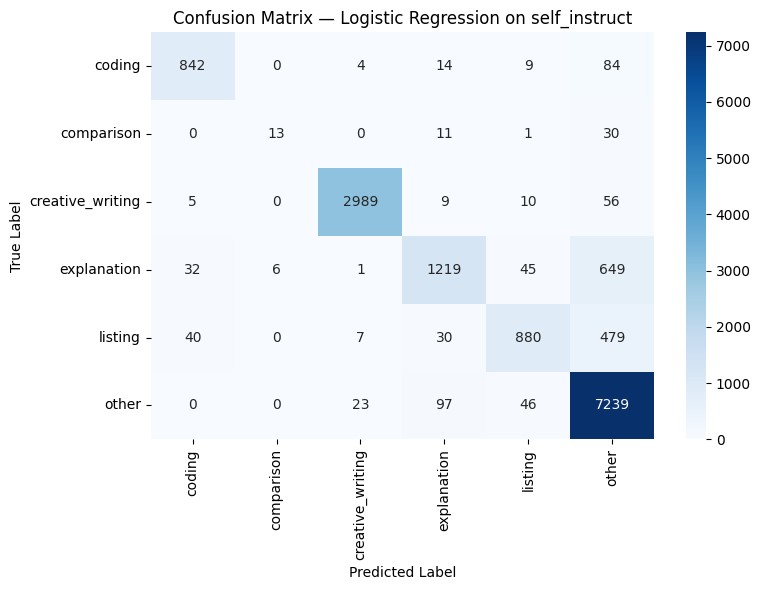

Confusion matrix saved as confusion_matrix.png

Top 10 features per class:
  coding: classify, code, python, class, implement, function, classified, classes, classify following, classification
  comparison: difference, compare, differences, vs, pros, cons, pros cons, arrays, numbers, different
  creative_writing: write, create, generate, rewrite, compose, writer, task write, list, write program, task create
  explanation: explain, described, describes, probability, situation, process, capital germany, meant, difference, best describes
  listing: list, provided, names, summarize, provide, named, example, detailed, advice, suggestions
  other: predict, identify, tell, detect, calculate, recommend, design, come, task tell, detailed description


In [ ]:
# ============================================================
# EXTRA CREDIT: ML for Business I — Logistic Regression
# Dataset: HuggingFaceH4/self_instruct
# Task: Classify prompt into instruction category
# ============================================================

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load dataset ──────────────────────────────────────────
dataset = load_dataset("HuggingFaceH4/self_instruct", split="train")
df = pd.DataFrame(dataset)
print(f"Dataset size: {len(df)} rows")
print(df.head())

# ── 2. Auto-label prompts into categories ────────────────────
def label_prompt(prompt):
    prompt = prompt.lower()
    if any(w in prompt for w in ["write", "draft", "compose", "create a", "generate a"]):
        return "creative_writing"
    elif any(w in prompt for w in ["explain", "what is", "how does", "why does", "describe"]):
        return "explanation"
    elif any(w in prompt for w in ["list", "give me", "provide", "name", "summarise", "summarize"]):
        return "listing"
    elif any(w in prompt for w in ["code", "implement", "function", "class", "python", "sql"]):
        return "coding"
    elif any(w in prompt for w in ["compare", "difference", "pros and cons", "versus", "vs"]):
        return "comparison"
    else:
        return "other"

df["label"] = df["prompt"].apply(label_prompt)

print("\nLabel distribution:")
print(df["label"].value_counts())

# ── 3. Filter out underrepresented classes ───────────────────
min_samples = 10
label_counts = df["label"].value_counts()
valid_labels = label_counts[label_counts >= min_samples].index
df = df[df["label"].isin(valid_labels)]
print(f"\nFiltered dataset size: {len(df)} rows")
print(f"Classes kept: {list(valid_labels)}")

# ── 4. TF-IDF Vectorization ──────────────────────────────────
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    stop_words="english"
)

X = vectorizer.fit_transform(df["prompt"])
y = df["label"]

# ── 5. Train/test split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

# ── 6. Train Logistic Regression ─────────────────────────────
clf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=42
)
clf.fit(X_train, y_train)

# ── 7. Evaluate ──────────────────────────────────────────────
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"\n{'='*50}")
print(f"  Accuracy:          {accuracy:.4f}")
print(f"  F1 (macro):        {f1_macro:.4f}")
print(f"  F1 (weighted):     {f1_weighted:.4f}")
print(f"{'='*50}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── 8. Confusion matrix plot ─────────────────────────────────
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix — Logistic Regression on self_instruct")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

# ── 9. Top TF-IDF features per class ─────────────────────────
print("\nTop 10 features per class:")
feature_names = vectorizer.get_feature_names_out()
for i, class_label in enumerate(clf.classes_):
    top_indices = np.argsort(clf.coef_[i])[-10:][::-1]
    top_features = [feature_names[j] for j in top_indices]
    print(f"  {class_label}: {', '.join(top_features)}")